In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_disease_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
print(df.shape)
df.head()

(1040, 18)


,village_id,village_name,latitude,longitude,population,water_source_type,date,ph_level,turbidity_ntu,residual_chlorine_mg_l,bacterial_contamination,rainfall_mm,temperature_c,sanitation_index,historical_cases_last_4_weeks,disease_type,case_count,outbreak_risk_level
0,V001,Village_1,16.57454,74.31185,10470,pond,2024-01-07,6.84,1.95,0.456,0,13.1,32.4,0.34,0,diarrhea,8,High
1,V001,Village_1,16.57454,74.31185,10470,pond,2024-01-14,7.33,2.31,0.462,0,6.4,25.7,0.34,8,typhoid,18,High
2,V001,Village_1,16.57454,74.31185,10470,pond,2024-01-21,5.94,2.49,0.326,0,5.4,28.9,0.34,18,diarrhea,6,Medium
3,V001,Village_1,16.57454,74.31185,10470,pond,2024-01-28,6.58,1.78,0.382,0,8.6,28.0,0.34,6,cholera,2,Low
4,V001,Village_1,16.57454,74.31185,10470,pond,2024-02-04,6.99,2.84,0.274,0,7.0,37.4,0.34,2,hepatitis_a,6,Medium


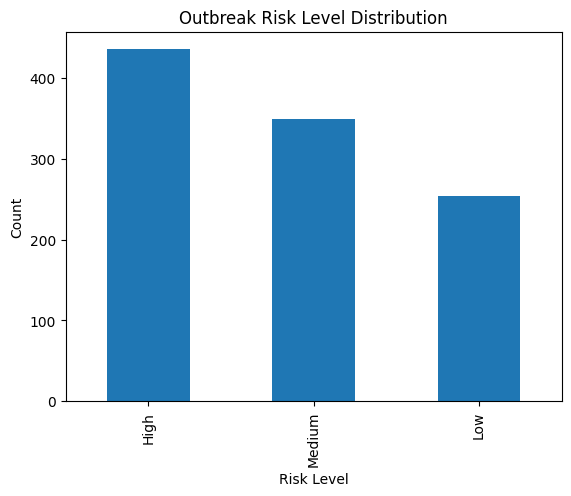

In [2]:
df["outbreak_risk_level"].value_counts().plot(kind="bar", title="Outbreak Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

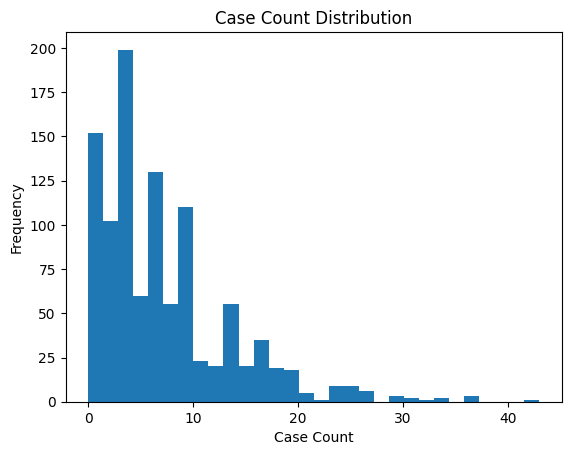

In [3]:
df["case_count"].plot(kind="hist", bins=30, title="Case Count Distribution")
plt.xlabel("Case Count")
plt.show()

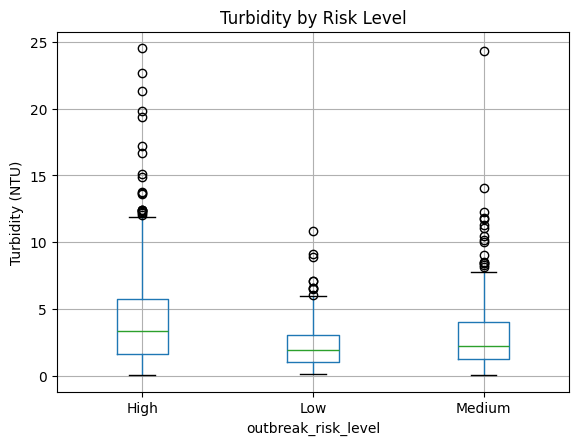

In [4]:
df.boxplot(column="turbidity_ntu", by="outbreak_risk_level")
plt.title("Turbidity by Risk Level")
plt.suptitle("")
plt.ylabel("Turbidity (NTU)")
plt.show()

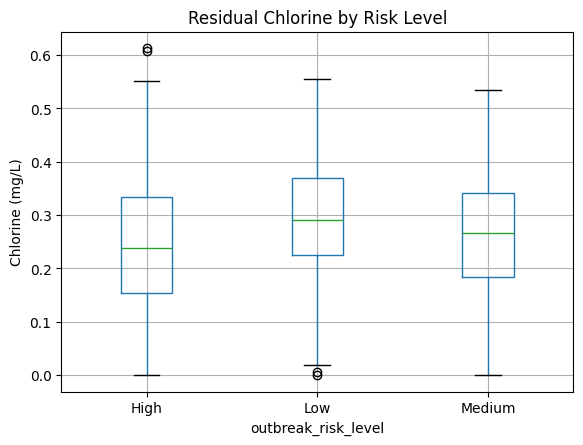

In [5]:

df.boxplot(column="residual_chlorine_mg_l", by="outbreak_risk_level")
plt.title("Residual Chlorine by Risk Level")
plt.suptitle("")
plt.ylabel("Chlorine (mg/L)")
plt.show()

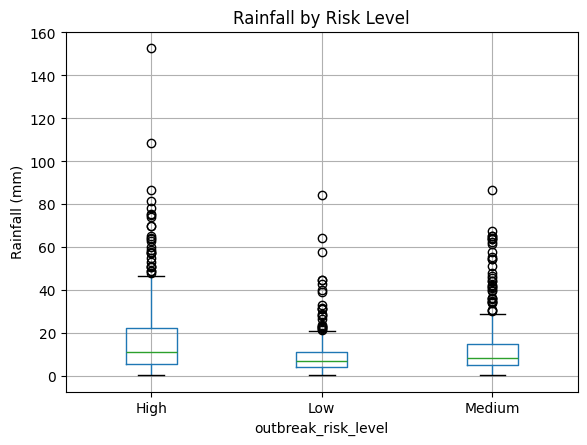

In [6]:
df.boxplot(column="rainfall_mm", by="outbreak_risk_level")
plt.title("Rainfall by Risk Level")
plt.suptitle("")
plt.ylabel("Rainfall (mm)")
plt.show()

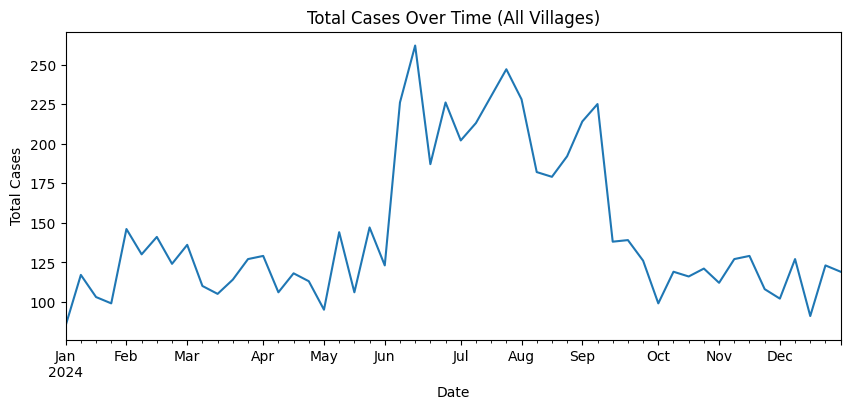

In [7]:
weekly_cases = df.groupby("date")["case_count"].sum()
weekly_cases.plot(kind="line", title="Total Cases Over Time (All Villages)", figsize=(10,4))
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.show()

In [8]:
numeric_df = df[["ph_level", "turbidity_ntu", "residual_chlorine_mg_l",
                  "bacterial_contamination", "rainfall_mm", "temperature_c",
                  "sanitation_index", "historical_cases_last_4_weeks", "case_count"]]

correlation = numeric_df.corr()
correlation

,ph_level,turbidity_ntu,residual_chlorine_mg_l,bacterial_contamination,rainfall_mm,temperature_c,sanitation_index,historical_cases_last_4_weeks,case_count
ph_level,1.000000,-0.000058,-0.015190,-0.033932,-0.009387,0.058751,0.005720,-0.008745,0.010707
turbidity_ntu,-0.000058,1.000000,-0.258290,0.482199,0.368175,-0.240661,-0.000986,0.095509,0.334536
residual_chlorine_mg_l,-0.015190,-0.258290,1.000000,-0.369074,-0.376590,0.279022,-0.022514,-0.124364,-0.204620
bacterial_contamination,-0.033932,0.482199,-0.369074,1.000000,0.284024,-0.193082,-0.007464,0.081910,0.306326
rainfall_mm,-0.009387,0.368175,-0.376590,0.284024,1.000000,-0.333467,0.007028,0.178262,0.243849
temperature_c,0.058751,-0.240661,0.279022,-0.193082,-0.333467,1.000000,0.005823,-0.230827,-0.209461
sanitation_index,0.005720,-0.000986,-0.022514,-0.007464,0.007028,0.005823,1.000000,-0.347041,-0.356253
historical_cases_last_4_weeks,-0.008745,0.095509,-0.124364,0.081910,0.178262,-0.230827,-0.347041,1.000000,0.619236
case_count,0.010707,0.334536,-0.204620,0.306326,0.243849,-0.209461,-0.356253,0.619236,1.000000


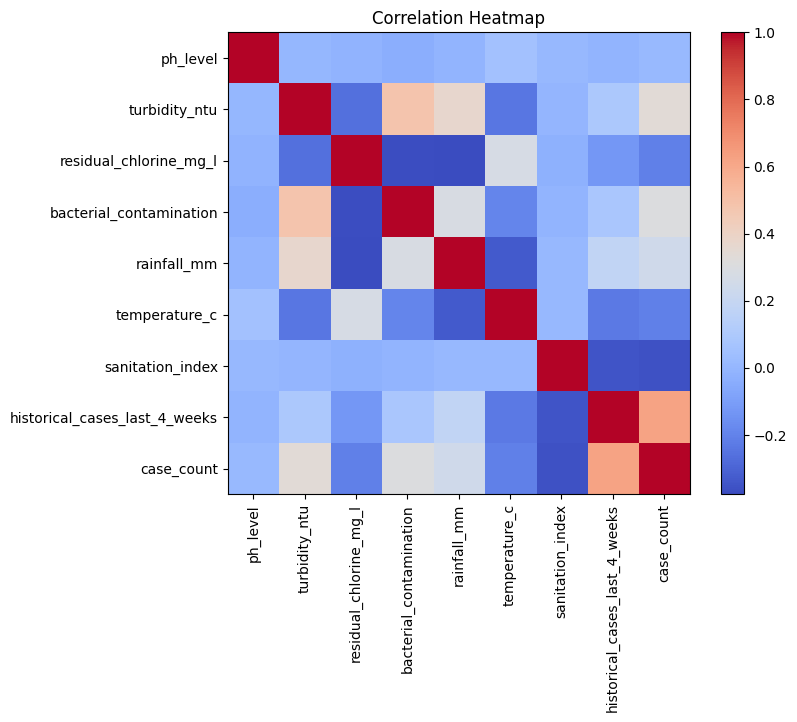

In [9]:
plt.figure(figsize=(8,6))
plt.imshow(correlation, cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Heatmap")
plt.show()